In [5]:
import torch
import numpy as np
from data import make_earth_dataloaders
from model import AmbientGeneratorScoreNet, DPnPScoreWrapper
from plot_earth import plot_earth_train_val_test, plot_earth_latlon, plot_sphere_3d,plot_points_on_earth
from train import train_ism_pathwise
from bel import get_bel
from test_earth import  test_dpnp_sampler_multiple_xtrue,cosine_similarity_vs_steps_for_particle_counts,make_aggregate_plot_from_results,replot_dpnp_results_for_xtrue,make_aggregate_plot_from_results
import matplotlib.pyplot as plt
from utils import get_vmf_f
device = "mps" if torch.backends.mps.is_available() else "cpu"

hidden_dim = 256
n_hidden_layers = 4
MODEL_PATH = "p_score_model_weights.pth" 
KAPPA = 30

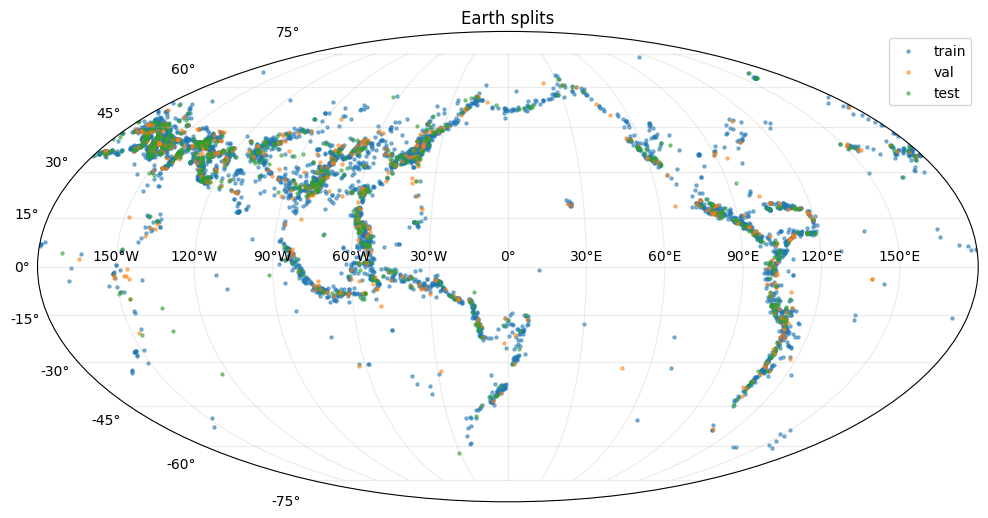

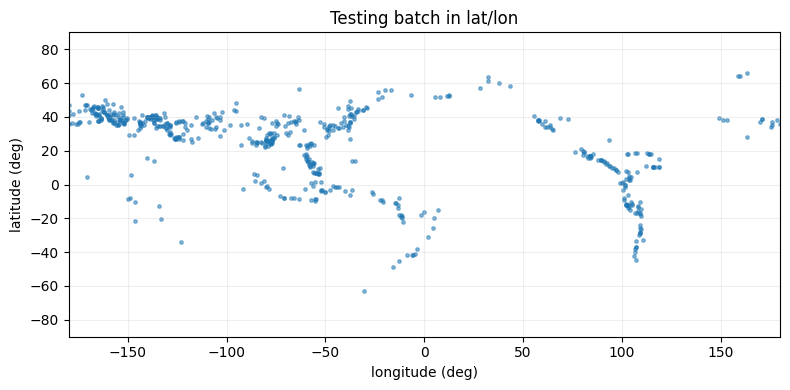

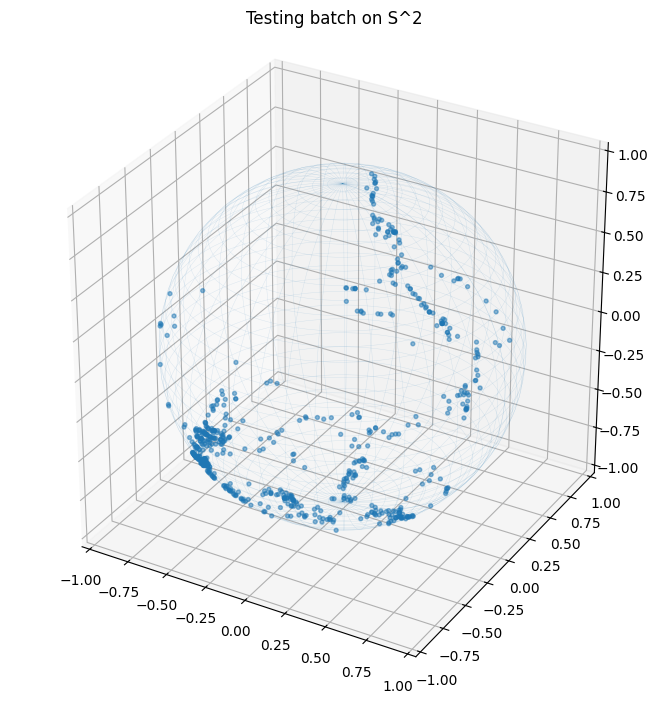

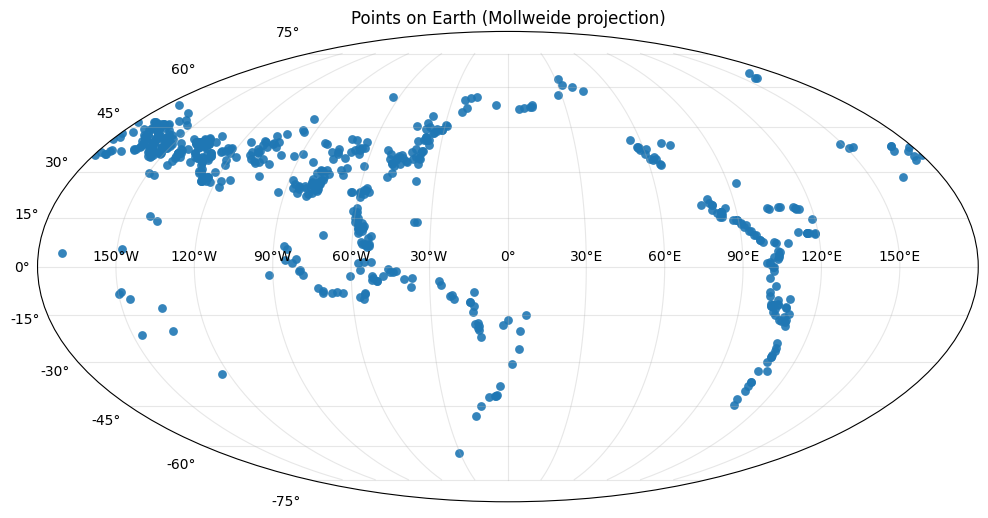

In [6]:
def p_score_model(train_loader, val_loader, test_loader, hidden_dim = hidden_dim, n_hidden_layers = n_hidden_layers, T = 1, lr = 2e-4, n_epochs = 20000,n_steps = 100):
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    model = AmbientGeneratorScoreNet(hidden_dim=hidden_dim, n_hidden_layers=n_hidden_layers)
    trained_model = train_ism_pathwise(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        T=T,
        lr=lr,
        n_epochs=n_epochs,
        n_steps=n_steps,
        device=device,
        log_every=100,
        eval_every=1000,
    )
    return trained_model

batch_size = 512
data_name = 'earthquake'
seed = 0
train_loader, val_loader, test_loader, dataset = make_earth_dataloaders(
        data_dir="data",
        name=data_name,   # change to: "fire", "flood", "volcano"
        batch_size=batch_size,
        seed=seed,
        device="cpu",        # keep raw data on CPU; train loop moves batches
    )
plot_earth_train_val_test(train_loader, val_loader, test_loader, title="Earth splits")
    
x_batch, _ = next(iter(test_loader))
plot_earth_latlon(x_batch, title="Testing batch in lat/lon")
plot_sphere_3d(x_batch, title="Testing batch on S^2")
plot_points_on_earth(x_batch)

In [3]:
trained_p_score_model = p_score_model(train_loader= train_loader, val_loader= val_loader, test_loader= test_loader)
torch.save(trained_p_score_model.state_dict(), MODEL_PATH)


KeyboardInterrupt: 

In [ ]:
cont_model = train_ism_pathwise(
    model=trained_p_score_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    n_epochs=40000,
    device="mps",
    checkpoint_dir="checkpoint",
    resume_path="checkpoint/latest.pt",
)

Resumed from epoch=20000 step=200000 best_val_loss=-17.262957
epoch=20009 step=200100 loss=-9.830934 t_mean=0.5177
epoch=20019 step=200200 loss=-14.389812 t_mean=0.5033
epoch=20029 step=200300 loss=-13.217719 t_mean=0.4896
epoch=20039 step=200400 loss=12.598518 t_mean=0.5064
epoch=20049 step=200500 loss=-22.174562 t_mean=0.5051
epoch=20059 step=200600 loss=-11.509447 t_mean=0.5092
epoch=20069 step=200700 loss=-22.845440 t_mean=0.4867
epoch=20079 step=200800 loss=-20.200544 t_mean=0.5013
epoch=20089 step=200900 loss=-25.061567 t_mean=0.5027
epoch=20099 step=201000 loss=-19.742275 t_mean=0.4969
[eval] step=201000 val_loss=-10.000689
epoch=20109 step=201100 loss=-7.290704 t_mean=0.4991
epoch=20119 step=201200 loss=-20.568668 t_mean=0.5155
epoch=20129 step=201300 loss=3.738050 t_mean=0.5189
epoch=20139 step=201400 loss=-26.715410 t_mean=0.5075
epoch=20149 step=201500 loss=-1.615553 t_mean=0.5245
epoch=20159 step=201600 loss=-9.184690 t_mean=0.4874
epoch=20169 step=201700 loss=-4.306875 t_m

In [7]:
def aneal_schedule(K:int = 20, K0:int = 5, eta0:float = 0.45, etaK:float = 0.15):
    etas = np.zeros(K)
    for i in range(K):
        if i < K0:
            etas[i] = eta0
        else:
            frac = (i-K0)/(K-K0)
            etas[i] = eta0 * ((etaK/eta0) ** frac)
    return etas

Model_to_load = 'p_score_3_stable.pth'
q_score = get_bel(f_fn= get_vmf_f(kappa=KAPPA))
p_model_loaded = AmbientGeneratorScoreNet(hidden_dim=hidden_dim, n_hidden_layers=n_hidden_layers)
# p_model_loaded.load_state_dict(torch.load(Model_to_load,weights_only=False))
p_model_loaded.eval().to(device)
p_score = DPnPScoreWrapper(p_model_loaded)
eta = aneal_schedule(K=20, K0=5, eta0  = 0.1, etaK  = 0.05)

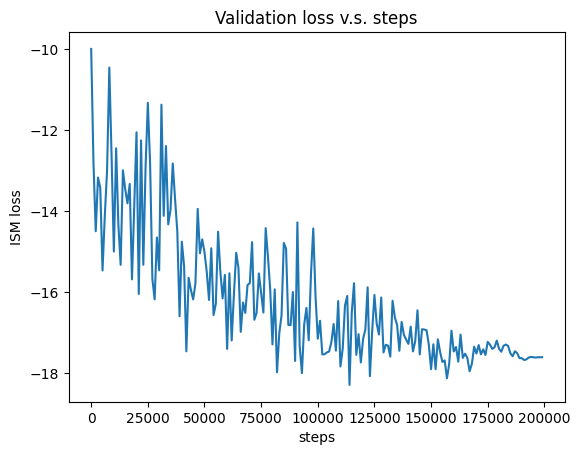

In [ ]:
loss_history = cont_model.loss_history
plt.title('Validation loss v.s. steps')
step = np.arange(len(loss_history)) * 1000
plt.xlabel('steps')
plt.ylabel('ISM loss')
plt.plot(step, loss_history)

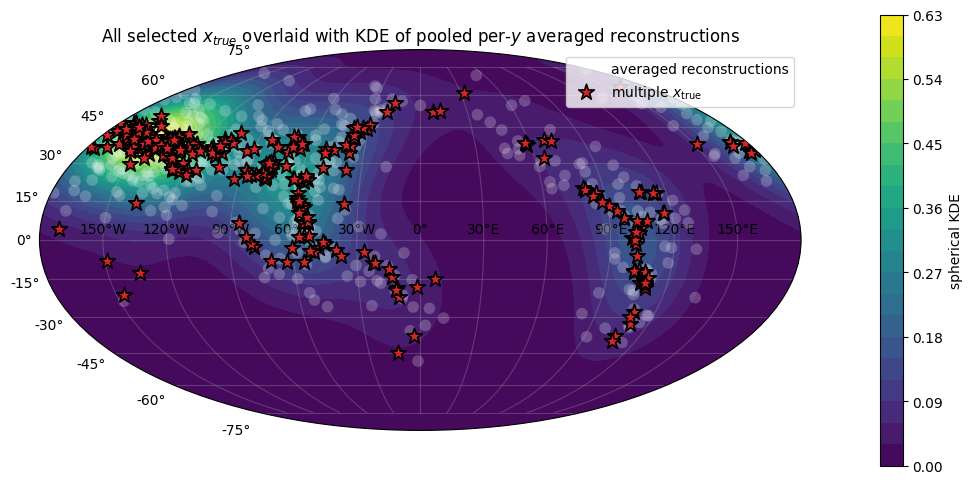

In [ ]:

results = test_dpnp_sampler_multiple_xtrue(
    dataloader=test_loader,
    q_score=q_score,
    p_score=p_score,
    eta=eta,
    sigma_y=KAPPA,
    num_xtrue=300,
    num_y_per_xtrue=32,
    out_samples=64,
    grw_steps=5,
    device="mps",
    dtype=torch.float32,
    seed=2,
    kappa=25.0,
    plot_results=False
)
save_dict = {
    "results": results,
    "sigma_y": KAPPA,
    "eta": eta,
    "num_y_per_xtrue": 32,
    "out_samples": 64,
    "grw_steps": 5,
    'num_xtrue': 80,
    'seed': 2,
    'kappa':25
}

torch.save(save_dict, "dpnp_test_results.pt")

In [ ]:
save_dict = {
    "results": results,
    "sigma_y": KAPPA,
    "eta": eta,
    "num_y_per_xtrue": 32,
    "out_samples": 64,
    "grw_steps": 5,
    'num_xtrue': 80,
    'seed': 2,
    'kappa':25
}

torch.save(save_dict, "dpnp_test_results.pt")

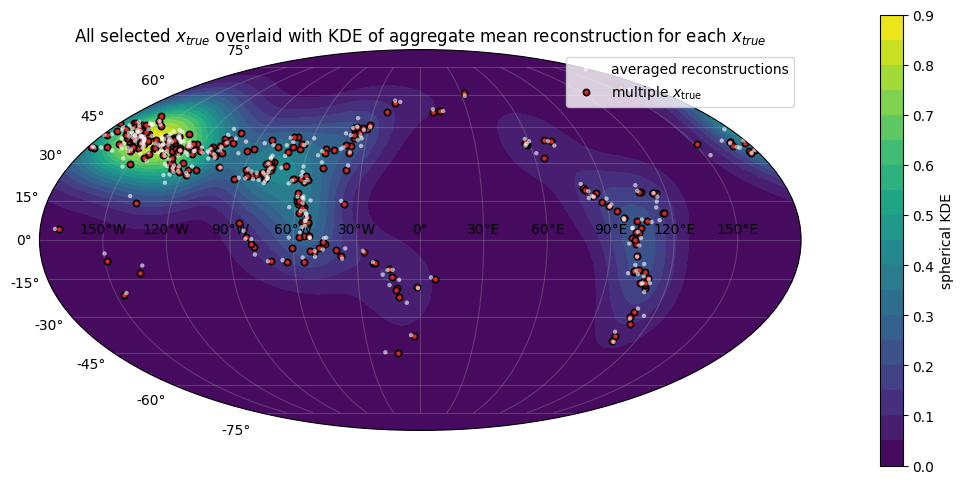

In [4]:
results = torch.load('earthquake-300-x.pt', weights_only=False)
n_overlay = 1000
level = 20
make_aggregate_plot_from_results(results=results['results'],kappa=25,overlay_count=n_overlay, levels=level,mode='x_global_mean',color='white',recon_size=10)



mean_obs_cos = 0.971667
N =   1, step 0 mean cos = -0.028802
N =   3, step 0 mean cos = -0.034285
N =   6, step 0 mean cos = -0.035248


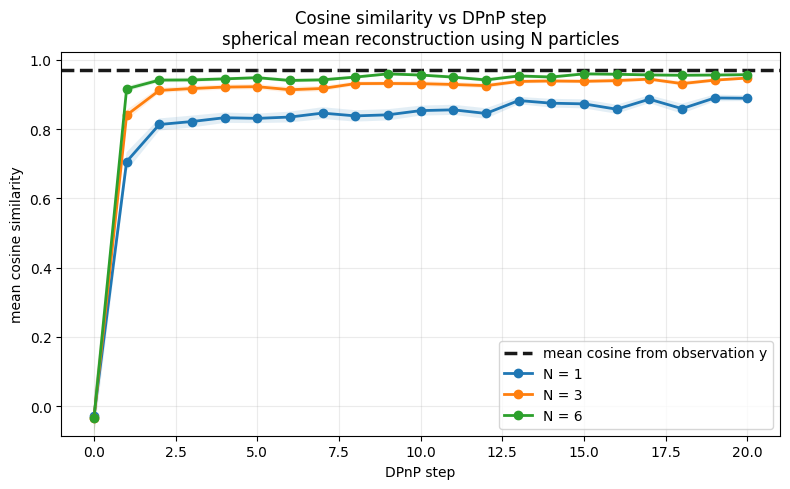

In [8]:
summary = cosine_similarity_vs_steps_for_particle_counts(
    dataloader=test_loader,
    q_score=q_score,
    p_score=p_score,
    eta=eta,
    sigma_y=KAPPA,
    particle_counts=[1, 3, 6],
    out_samples=10,
    grw_steps=5,
    num_pairs=100,
    batch_eval_size=16,
    device="mps",
    dtype=torch.float32,
    seed=0,
    show_stderr=True,
)

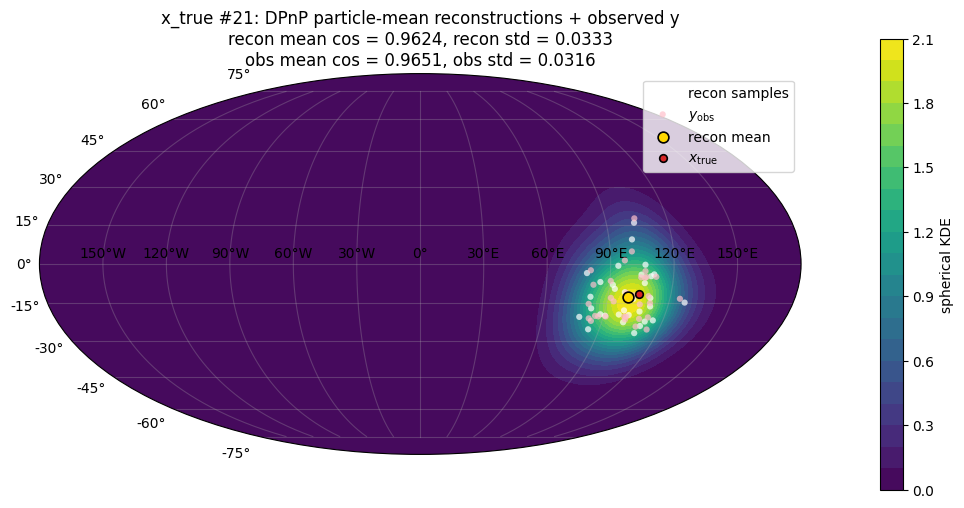

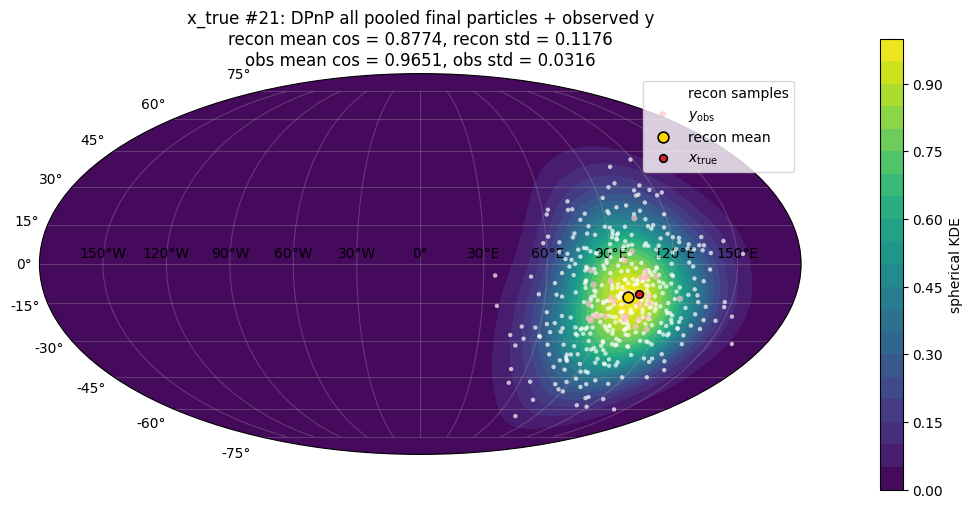

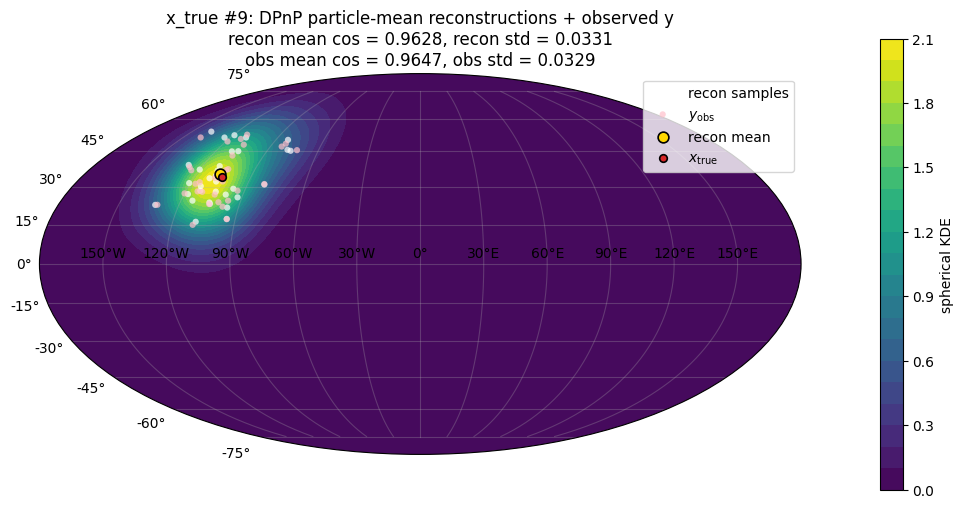

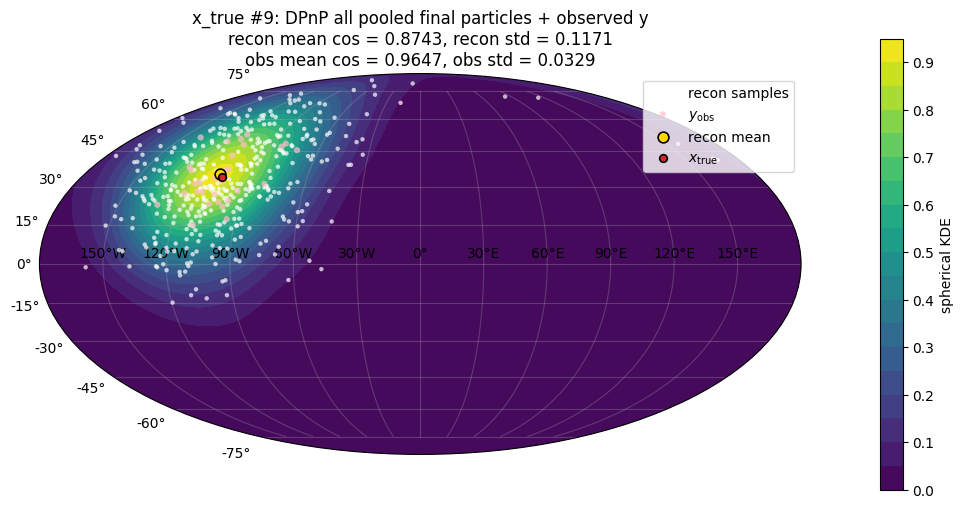

In [5]:
replot_dpnp_results_for_xtrue(results=results['results'],xtrue_idx=20)
replot_dpnp_results_for_xtrue(results=results['results'],xtrue_idx=8)